In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [5]:
df = pd.read_csv("ChickWeight.csv")
print(df.head())

   Unnamed: 0  weight  Time  Chick  Diet
0           1      42     0      1     1
1           2      51     2      1     1
2           3      59     4      1     1
3           4      64     6      1     1
4           5      76     8      1     1


In [12]:
# print(df["Chick"].value_counts())

In [13]:
df_chick6 = df[df["Chick"] == 6][['weight', 'Time']]

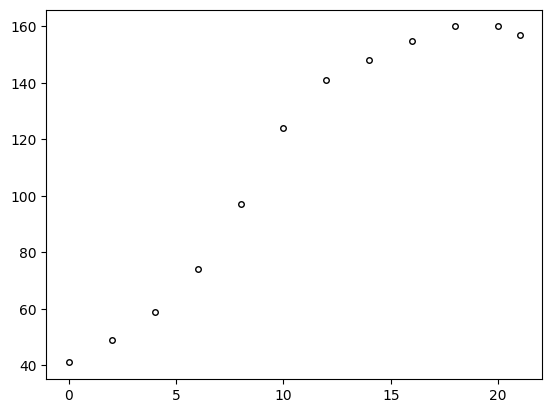

In [15]:
y = df_chick6['weight']
X = df_chick6['Time']

plt.plot(X, y, 'o', markersize=4, fillstyle='none', color='black')

In [19]:
X_sm = sm.add_constant(X)
model_linear = sm.OLS(y, X_sm).fit()
print(model_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     124.3
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           5.83e-07
Time:                        17:57:50   Log-Likelihood:                -47.103
No. Observations:                  12   AIC:                             98.21
Df Residuals:                      10   BIC:                             99.18
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.1234      7.351      6.002      0.0

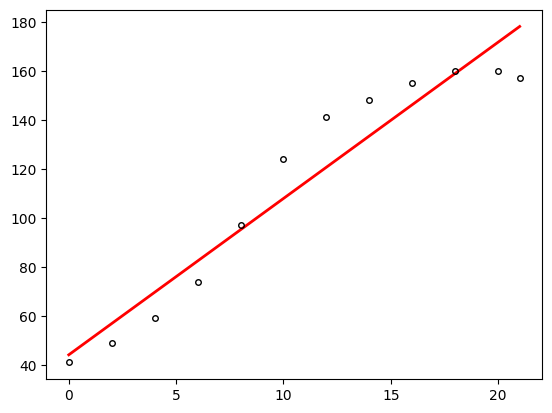

In [20]:
X_vals = np.linspace(X.min(), X.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model_linear.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X, y, 'o', markersize=4, fillstyle='none', color='black')
plt.show()

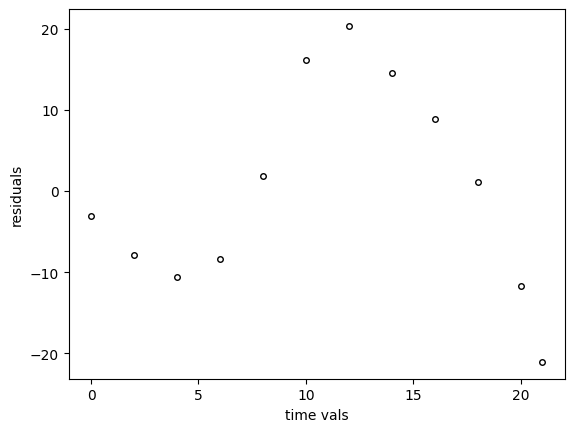

In [40]:
residuals_linear = model_linear.resid
fitted_linear = model_linear.fittedvalues

plt.plot(X, residuals_linear, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel('time vals')
plt.ylabel('residuals')
plt.show()

In [36]:
X_poly = np.vander(X, N=5, increasing=True)

model_poly = sm.OLS(y, X_poly).fit()
print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     529.8
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           9.19e-09
Time:                        18:13:04   Log-Likelihood:                -28.389
No. Observations:                  12   AIC:                             66.78
Df Residuals:                       7   BIC:                             69.20
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.7758      3.212     13.318      0.0

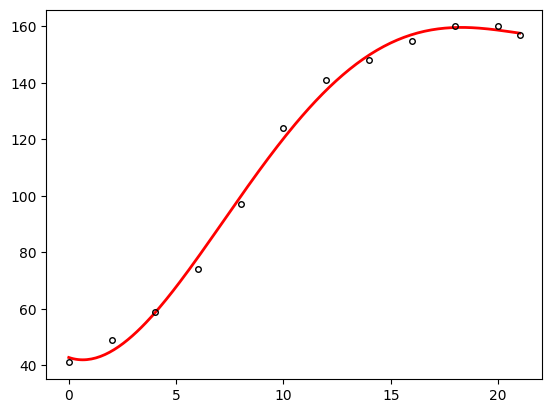

In [37]:
X_vals = np.linspace(X.min(), X.max(), 200)
X_vals_sm = np.vander(X_vals, N=5, increasing=True)
y_vals = model_poly.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X, y, 'o', markersize=4, fillstyle='none', color='black')
plt.show()

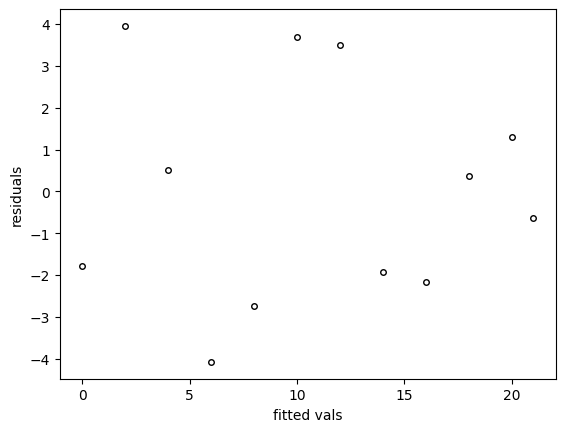

In [39]:
residuals_poly = model_poly.resid
fitted_poly = model_poly.fittedvalues

plt.plot(X, residuals_poly, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel('fitted vals')
plt.ylabel('residuals')
plt.show()

# Part c - using all the data

In [43]:
X_all = df["Time"]
y_all = df["weight"]

X_all_sm = sm.add_constant(X_all)

model_all_linear = sm.OLS(y_all, X_all_sm).fit()

print(model_all_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     1349.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):          5.02e-153
Time:                        18:51:42   Log-Likelihood:                -2935.4
No. Observations:                 578   AIC:                             5875.
Df Residuals:                     576   BIC:                             5884.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.4674      3.036      9.046      0.0

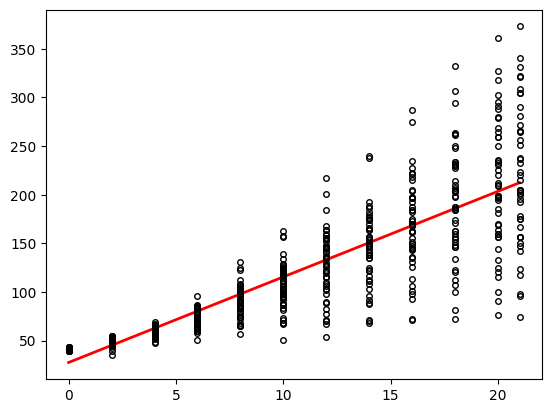

In [45]:
X_vals = np.linspace(X_all.min(), X_all.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model_all_linear.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X_all, y_all, 'o', markersize=4, fillstyle='none', color='black')
plt.show()

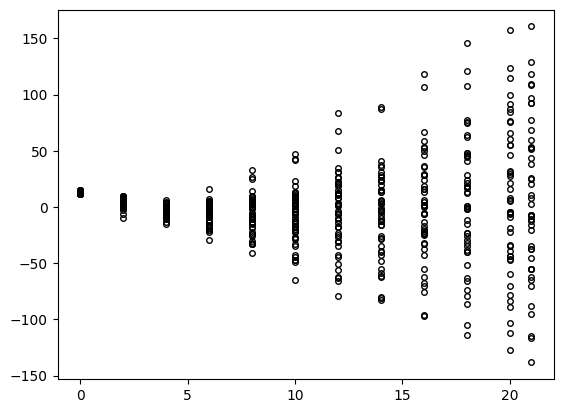

In [47]:
residuals = model_all_linear.resid

plt.plot(X_all, residuals, 'o', markersize=4, fillstyle='none', color='black')

In [54]:
X_all_poly = np.vander(X_all, N=4, increasing=True)

model_all_poly = sm.OLS(y_all, X_all_poly).fit()

print(model_all_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     465.9
Date:                Mon, 16 Feb 2026   Prob (F-statistic):          2.48e-153
Time:                        19:11:46   Log-Likelihood:                -2927.4
No. Observations:                 578   AIC:                             5863.
Df Residuals:                     574   BIC:                             5880.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.8934      4.791      8.535      0.0

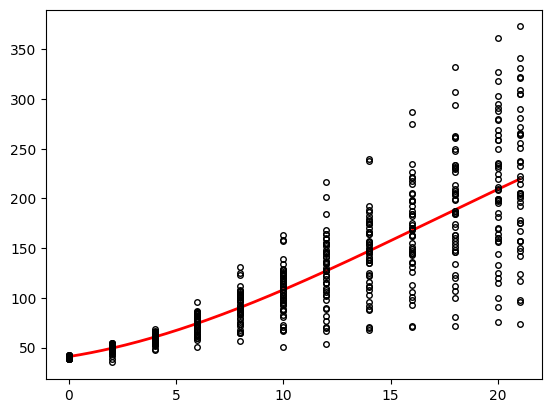

In [55]:
X_vals = np.linspace(X_all.min(), X_all.max(), 200)
X_vals_sm = np.vander(X_vals, N=4, increasing=True)
y_vals = model_all_poly.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X_all, y_all, 'o', markersize=4, fillstyle='none', color='black')
plt.show()

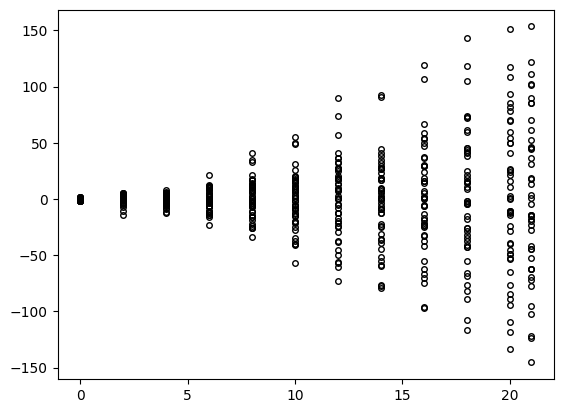

In [58]:
residuals = model_all_poly.resid

plt.plot(X_all, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.show()

All the same issues still prevail - heteroscedasticity, bad model fit